In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image


%matplotlib inline

# VARIABLES DICCIONARIO

- sexo: sexo del estudiante (1: mujer)

- edad: edad del estudiante (meses)

- imce: indice de masa corporal estandarizado (puntaje z)

- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)

- vive_madre: 2(__es 1, modificación__) si la madre vive en el hogar (2 indica que tiene mas de una madre)

- area: urbana=1, rural=0

- sk1: muestra afecto a padres (1: siempre - 5: nunca)

- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)

- sk3: expresa sus sentimientos (1: siempre - 5: nunca)

- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)

- sk5: juega con otros (1: siempre - 5: nunca)

- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)

- sk7: es agresivo (1: siempre - 5: nunca)

- sk8: participa en juegos grupales (1: siempre - 5: nunca)

- sk9: hace preguntas a adultos (1: siempre - 5: nunca)

- sk10: tiene interes por libros (1: siempre - 5: nunca)

- sk11: tiene interes por su entorno (1: siempre - 5: nunca)

- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca)

- sk13: tiene expresiones artisticas (1: siempre - 5: nunca)

- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)

- educm: años de escolaridad de la madre

- educp: años de escolaridad del padre

- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

In [2]:
df=pd.read_csv("../data/junaeb3.csv")

In [3]:
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,...,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


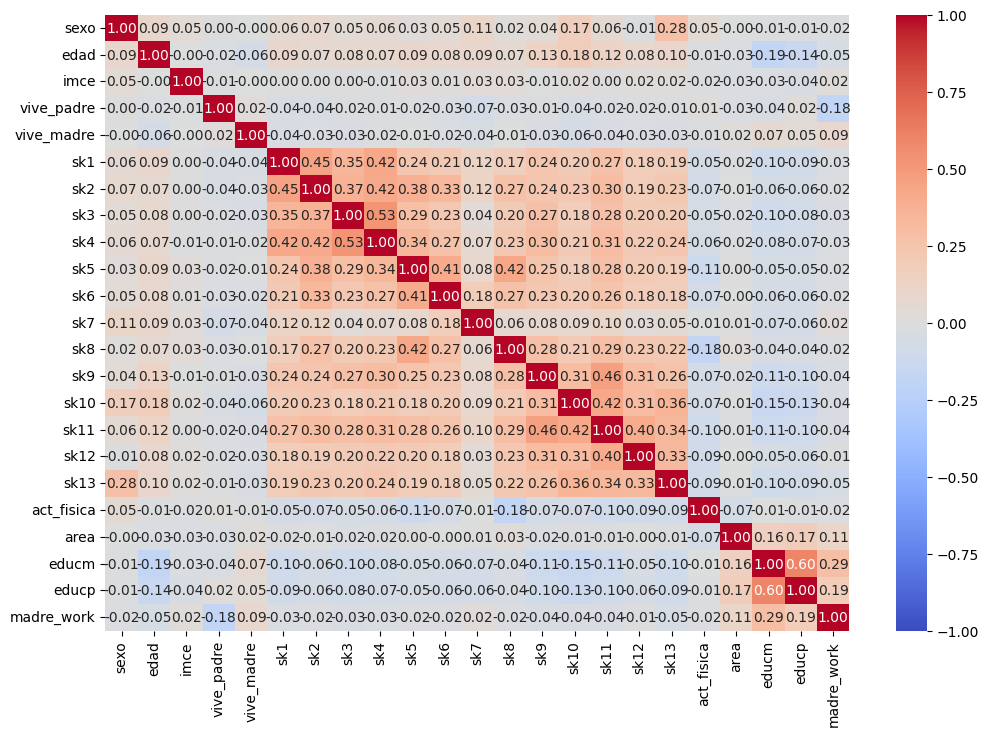

In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    annot_kws={"size":10}
)
plt.show()

# revisamos valores anormales

In [5]:
df["sexo"].unique()

array([1, 0])

In [6]:
print(min(df["edad"]), # 5 a 9 años aprox la edad
max(df["edad"]))

62 107


In [7]:
107/12

8.916666666666666

In [8]:
print(df["vive_madre"].value_counts(),"\n \n",df["vive_padre"].value_counts(),"\n \n",
      df["area"].value_counts(dropna=False),"\n \n")
      

vive_madre
1    29903
0     1096
2       56
Name: count, dtype: int64 
 
 vive_padre
1    22354
0     8693
2        8
Name: count, dtype: int64 
 
 area
1    28308
0     2747
Name: count, dtype: int64 
 



In [9]:
print(df["educm"].value_counts(),"\n \n",
      df["educp"].value_counts(),"\n \n",
      )

educm
13.0    13180
9.0      2615
15.0     1886
11.0     1807
16.0     1707
18.0     1629
17.0     1601
12.0     1040
10.0      976
14.0      760
20.0      615
22.0      542
7.0       532
8.0       522
6.0       325
5.0       304
19.0      237
4.0       165
3.0       116
0.0        66
2.0        57
Name: count, dtype: int64 
 
 educp
13    13376
9      3089
11     2168
17     1713
15     1523
18     1484
16     1243
10     1080
12     1052
20      855
14      564
7       545
22      543
8       434
19      320
5       317
6       276
4       186
3       132
0        93
2        62
Name: count, dtype: int64 
 



# revisamos nans

In [10]:
df.isna().sum() #hay pocos, los modelos a ocupar piden su ausencia, lo buneo que de sk 1 a 13 no hay

sexo             0
edad             0
imce             0
vive_padre       0
vive_madre       0
sk1              0
sk2              0
sk3              0
sk4              0
sk5              0
sk6              0
sk7              0
sk8              0
sk9              0
sk10             0
sk11             0
sk12             0
sk13             0
act_fisica    1004
area             0
educm          373
educp            0
madre_work       0
dtype: int64

In [11]:
len(df)

31055

In [12]:
print(len(df))
df=df.dropna(subset="act_fisica")
print(len(df))

31055
30051


In [13]:
df=df.dropna(subset="educm")
len(df)

29696

In [14]:
df_nan = df[df.isna().any(axis=1)]
df_nan.head(50)

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work


In [15]:
df.isna().sum()

sexo          0
edad          0
imce          0
vive_padre    0
vive_madre    0
sk1           0
sk2           0
sk3           0
sk4           0
sk5           0
sk6           0
sk7           0
sk8           0
sk9           0
sk10          0
sk11          0
sk12          0
sk13          0
act_fisica    0
area          0
educm         0
educp         0
madre_work    0
dtype: int64

# revisamos outliers

In [16]:
df["sk13"].unique() #probamos con todos y ninguno tiene datos anormales, todos los sk tiene 1 2 3 4 o 5 solamente

array([1, 2, 4, 3, 5])

In [17]:
df1=df[['sk1', 'sk2', 'sk3',
       'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12',
       'sk13']]
df1

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
1,1,1,1,1,1,1,4,1,1,1,1,1,1
3,1,1,1,1,1,1,2,1,1,1,1,1,1
4,1,1,1,1,1,1,3,1,1,1,1,1,1
5,1,2,1,1,1,1,4,1,1,1,1,1,1
6,1,1,1,2,2,2,3,2,3,3,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,1,3,1,2,2,1,1,3,2,2,2,1,1
31051,1,1,2,2,1,1,1,2,1,3,2,1,4
31052,1,1,1,1,1,1,1,1,1,3,1,1,1
31053,1,1,1,1,2,2,1,2,1,2,1,1,2


<Axes: >

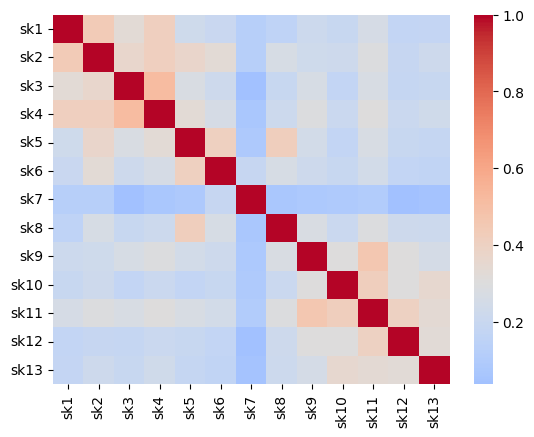

In [18]:
sns.heatmap(df1.corr(),cmap="coolwarm", center=0.30)

In [19]:
pca = PCA(n_components=13)
pca_features = pca.fit_transform(df1)
print(pca.explained_variance_ratio_)

[0.28732908 0.18595434 0.10025747 0.07968822 0.06627543 0.06442256
 0.05212843 0.04403429 0.03243927 0.02898623 0.02484142 0.02079568
 0.01284758]


# Pregunta 2

In [20]:
fa = FactorAnalyzer(rotation='varimax').fit(df1)

d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [21]:
df1.columns

Index(['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10',
       'sk11', 'sk12', 'sk13'],
      dtype='object')

In [22]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_ #nos arroja 3 factores

array([[0.171221, 0.540217, 0.151458],
       [0.174149, 0.512531, 0.354330],
       [0.179785, 0.587108, 0.161938],
       [0.195805, 0.685256, 0.194526],
       [0.121301, 0.214133, 0.716727],
       [0.162524, 0.203313, 0.486711],
       [0.070301, 0.074530, 0.146613],
       [0.269211, 0.097481, 0.478541],
       [0.495887, 0.205273, 0.201636],
       [0.555989, 0.121166, 0.127875],
       [0.665920, 0.206954, 0.202009],
       [0.524127, 0.109526, 0.141501],
       [0.480548, 0.151480, 0.131725]])

In [23]:
# Mostrar la relación entre los nombres de las columnas de df1 y las cargas factoriales de fa
print("        FACTOR 1  FACTOR 2  FACTOR 3")
for i, col in enumerate(df1.columns):
    print(f"{col} -> {fa.loadings_[i]}")
    print(f"VALOR MAXIMO -> {max(fa.loadings_[i])} " \
    f"PErtenece al factor -> {np.argmax(fa.loadings_[i])+1}")
    print("\n")


        FACTOR 1  FACTOR 2  FACTOR 3
sk1 -> [0.171221 0.540217 0.151458]
VALOR MAXIMO -> 0.5402172337490964 PErtenece al factor -> 2


sk2 -> [0.174149 0.512531 0.354330]
VALOR MAXIMO -> 0.5125312056354531 PErtenece al factor -> 2


sk3 -> [0.179785 0.587108 0.161938]
VALOR MAXIMO -> 0.5871075837335075 PErtenece al factor -> 2


sk4 -> [0.195805 0.685256 0.194526]
VALOR MAXIMO -> 0.6852555692945741 PErtenece al factor -> 2


sk5 -> [0.121301 0.214133 0.716727]
VALOR MAXIMO -> 0.7167265444773256 PErtenece al factor -> 3


sk6 -> [0.162524 0.203313 0.486711]
VALOR MAXIMO -> 0.48671058090988484 PErtenece al factor -> 3


sk7 -> [0.070301 0.074530 0.146613]
VALOR MAXIMO -> 0.14661347127040691 PErtenece al factor -> 3


sk8 -> [0.269211 0.097481 0.478541]
VALOR MAXIMO -> 0.4785411203226863 PErtenece al factor -> 3


sk9 -> [0.495887 0.205273 0.201636]
VALOR MAXIMO -> 0.4958873723760414 PErtenece al factor -> 1


sk10 -> [0.555989 0.121166 0.127875]
VALOR MAXIMO -> 0.555989262013226 PErtenec

In [24]:
len(df1.columns)
df1.columns

Index(['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10',
       'sk11', 'sk12', 'sk13'],
      dtype='object')

In [25]:
len(fa.loadings_)

13

In [26]:
fa.get_eigenvalues()


(array([4.034140, 1.350905, 1.114858, 1.001343, 0.791246, 0.707033,
        0.701430, 0.690630, 0.608183, 0.529379, 0.517172, 0.491397,
        0.462285]),
 array([3.438847, 0.745863, 0.522710, 0.217186, 0.117540, 0.062923,
        0.007478, -0.011080, -0.034611, -0.063772, -0.082158, -0.084646,
        -0.128859]))

In [27]:
fa.get_communalities()


array([0.344091, 0.418566, 0.403242, 0.545755, 0.574264, 0.304637,
       0.031992, 0.310979, 0.328698, 0.340157, 0.527086, 0.306728,
       0.271224])

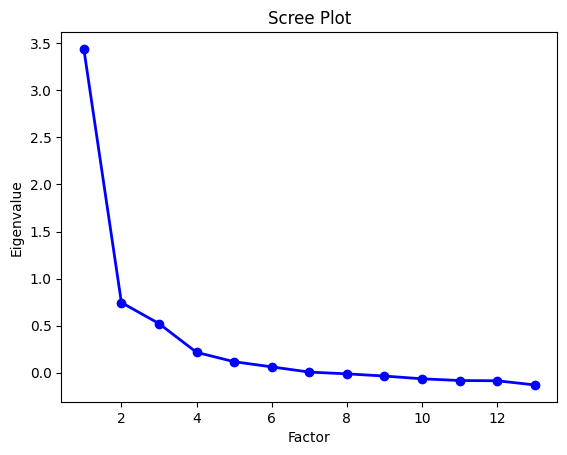

In [28]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[1], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

# Respuesta pregunta 2
# variables y factores (se determinaron 3 factores)
- sk1 -> Factor 2
- sk2 -> Factor 2
- sk3 -> Factor 2
- sk4 -> Factor 2
- sk5 -> Factor 3
- sk6 -> Factor 3
- sk7 -> Factor 3
- sk8 -> Factor 3
- sk9 -> Factor 1
- sk10 -> Factor 1
- sk11 -> Factor 1
- sk12 -> Factor 1
- sk13 -> Factor 1

se obtuvo lo anterior en cuanto a factores
 - 5 variables al factor 1 (sk 13 / 12 / 11/ 10/ 9)
 - 4 vaariables al factor 2 (sk 8 / 7 / 6/ 5)
 - 4 variables al factor 3 (sk 4 / 3 / 2/ 1)

 __Cabe recalcar que sk7 es sospechoso de no ser una variable informativa, pues si, tiene asignado el factor 3, mas su coeficiente es bastante bajo en comparación al resto, y por supuesto, los demas valores aun más bajos, por lo que, mas que decir que pertenece al factor 3, se podria decir a cuales factores pertenece menos, y por "descarte" se le asigno uno(el 3). Al menos de lo que arroja este analisis.__

 Respeco a la decision de 3 factores: se eligieron 3 puesto que el incremento a partir del 4 factor es marginal en cuanto a variabilidad explicada, ademas notemos que en output de comunalities, podemos observar como la variable sk7(su varianza) es muy poco explicada por los factores, lo que re afirma el hecho de su firmeza con respecto a su pertenencia a uno de estos

 - nota: Curiosamente pareciera que el que decidio tomar estas variables, penso en algun aspecto, coloco todo lo que creyo importante, y luego en otro aspecto y asi, o quizas no, pero es curioso que tengan cierto orden...

In [29]:
values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])

In [30]:
eigenvalues

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,4.034140,1.350905,1.114858,1.001343,0.791246,0.707033,0.701430,0.69063,0.608183,0.529379,0.517172,0.491397,0.462285
1,3.438847,0.745863,0.522710,0.217186,0.117540,0.062923,0.007478,-0.01108,-0.034611,-0.063772,-0.082158,-0.084646,-0.128859


In [31]:
fa.get_factor_variance()

(array([1.752965, 1.605630, 1.348825]),
 array([0.134843, 0.123510, 0.103756]),
 array([0.134843, 0.258353, 0.362109]))

# Pregunta 3

In [32]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import numpy as np

fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(df1)
loadings = fa.loadings_  # 
loadings


d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[0.171221, 0.540217, 0.151458],
       [0.174149, 0.512531, 0.354330],
       [0.179785, 0.587108, 0.161938],
       [0.195805, 0.685256, 0.194526],
       [0.121301, 0.214133, 0.716727],
       [0.162524, 0.203313, 0.486711],
       [0.070301, 0.074530, 0.146613],
       [0.269211, 0.097481, 0.478541],
       [0.495887, 0.205273, 0.201636],
       [0.555989, 0.121166, 0.127875],
       [0.665920, 0.206954, 0.202009],
       [0.524127, 0.109526, 0.141501],
       [0.480548, 0.151480, 0.131725]])

In [33]:
#df con los factores para graficar
factor_df = pd.DataFrame(loadings, 
                         columns=['F1', 'F2', 'F3'], 
                         index=df1.columns)


In [34]:
factor_scores = fa.transform(df1)  # Esto proyecta los datos originales sobre los factores
scores_df = pd.DataFrame(factor_scores, columns=['F1', 'F2', 'F3'], index=df1.index)

#juntamos la data
dfa = pd.concat([df, scores_df], axis=1)



d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [35]:
df.columns

Index(['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'sk1', 'sk2', 'sk3',
       'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12',
       'sk13', 'act_fisica', 'area', 'educm', 'educp', 'madre_work'],
      dtype='object')

#graficamos todo

combinaciones= (F1,F3) (F1,F2) (F2,F3)

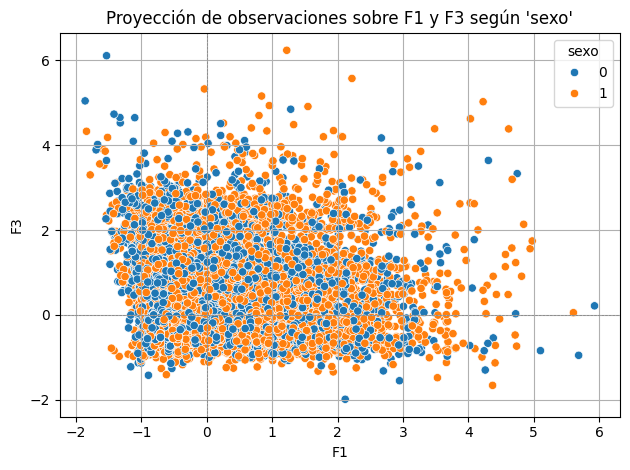

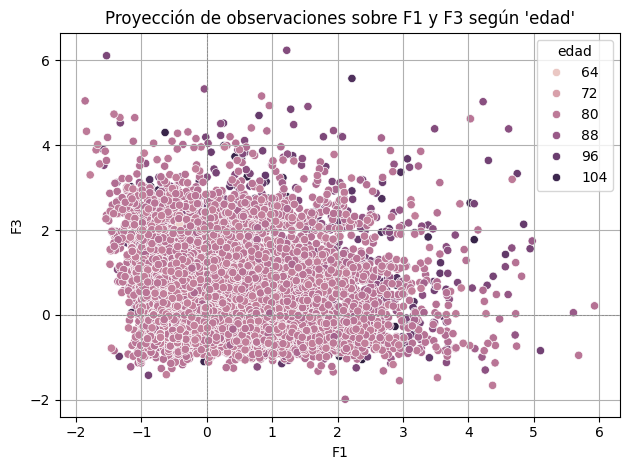

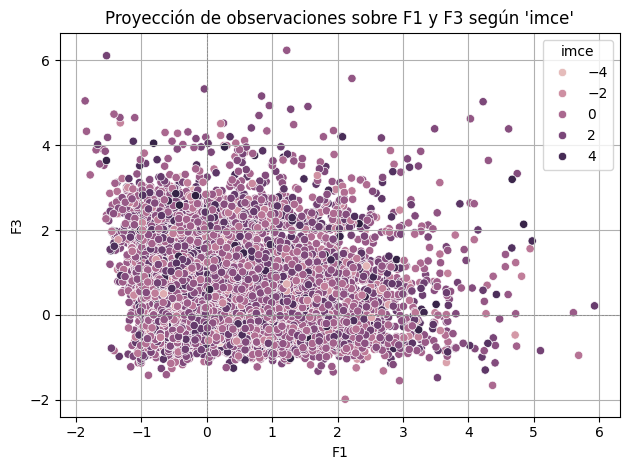

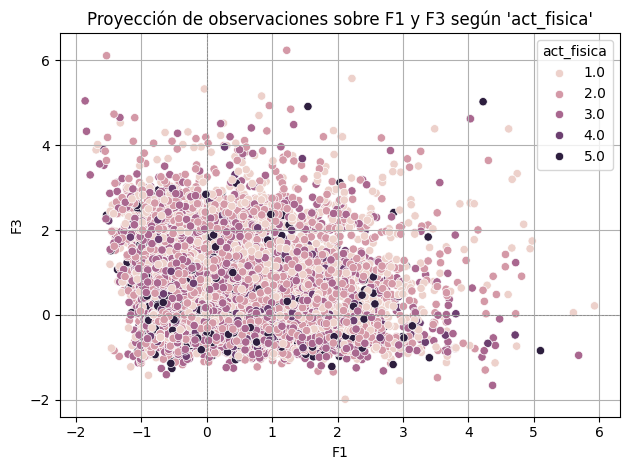

In [36]:
#COMBINACION F1 Y F3
import seaborn as sns
import matplotlib.pyplot as plt

variables_para_hue = ["sexo", "edad", "imce", "act_fisica"]

for variable in variables_para_hue:
    sns.scatterplot(data=dfa, x='F1', y='F3', hue=variable)  # Variable cambia en cada iteración
    plt.title(f"Proyección de observaciones sobre F1 y F3 según '{variable}'")
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



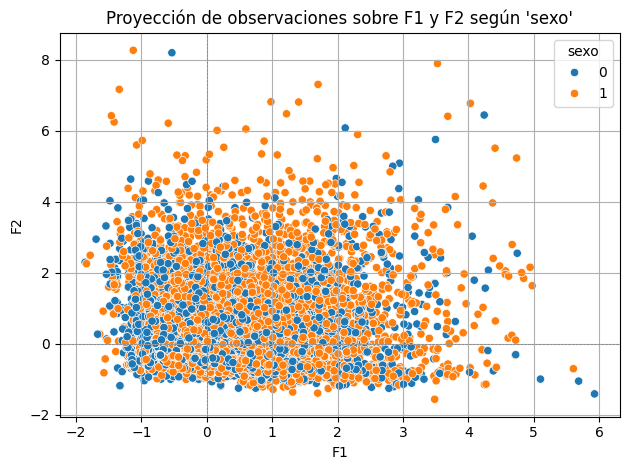

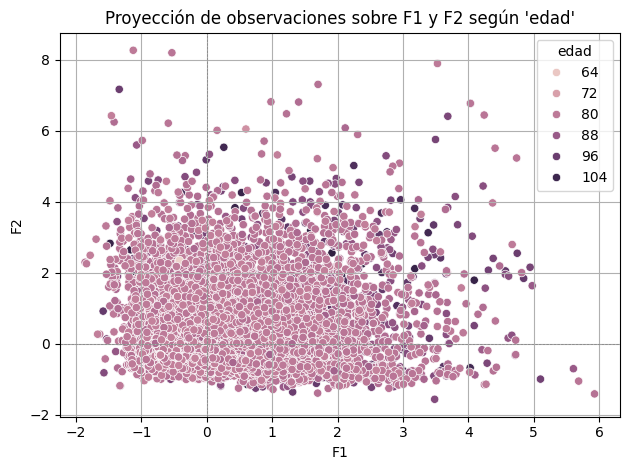

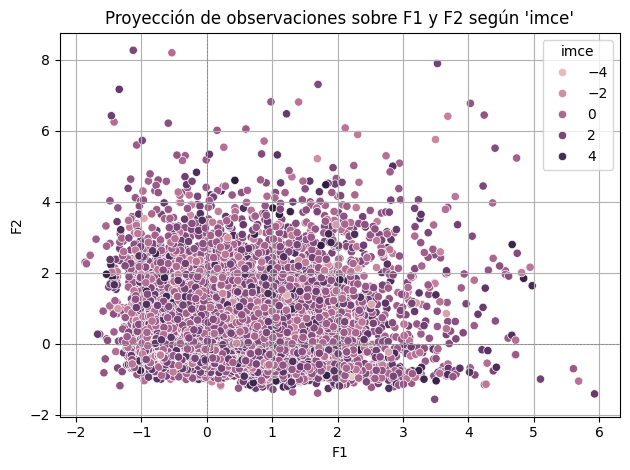

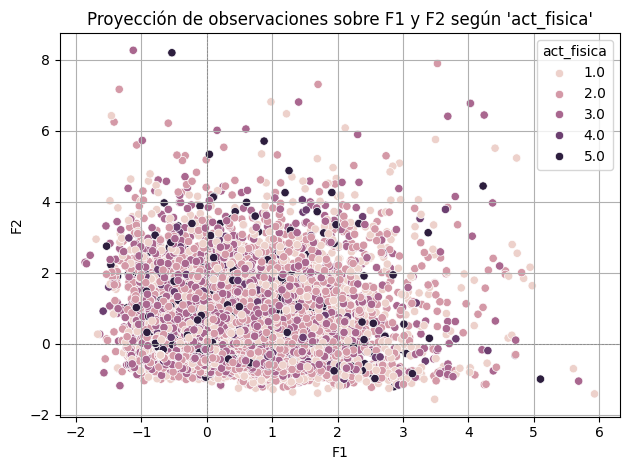

In [37]:
# COMBINACION F1 Y F2 (2)


for variable in variables_para_hue:
    sns.scatterplot(data=dfa, x='F1', y='F2', hue=variable)  # Variable cambia en cada iteración
    plt.title(f"Proyección de observaciones sobre F1 y F2 según '{variable}'")
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

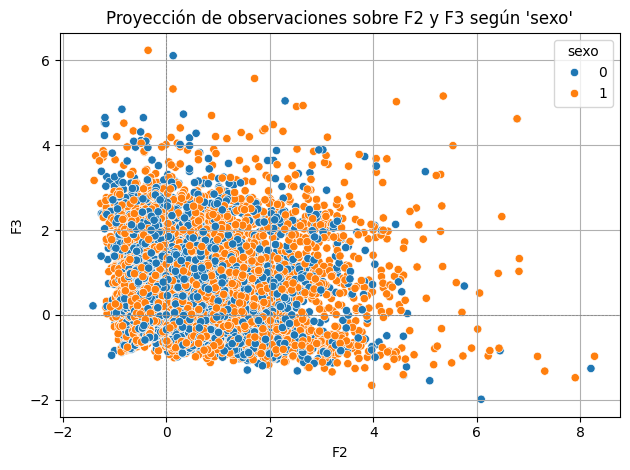

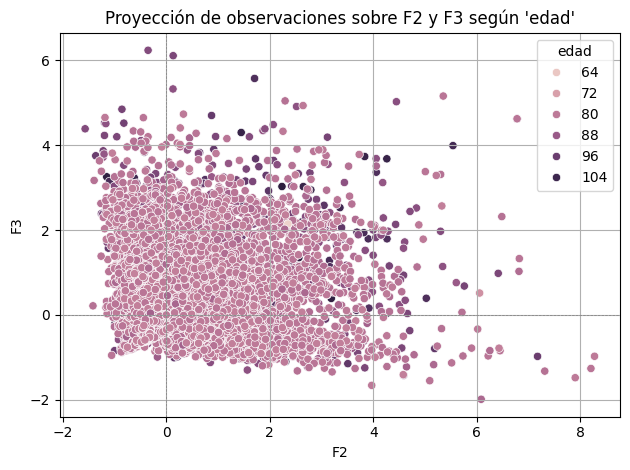

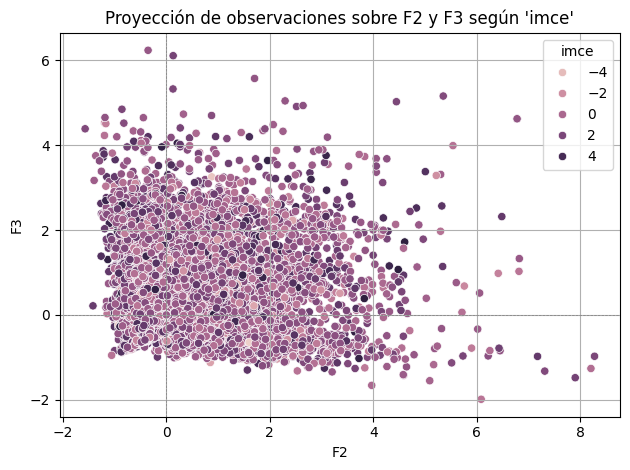

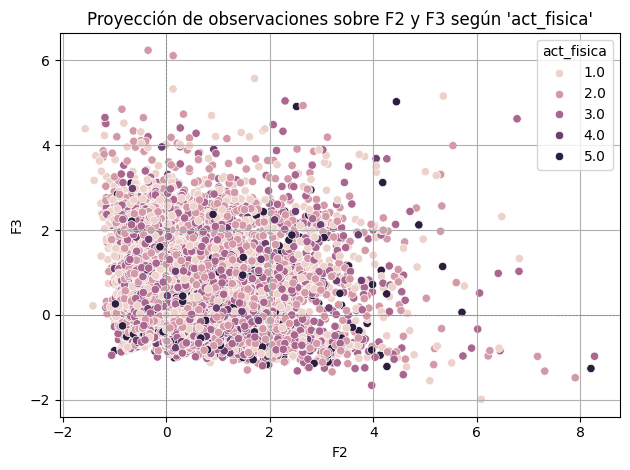

In [38]:
#COMBINACION F2 Y F3(3)

import seaborn as sns
import matplotlib.pyplot as plt

variables_para_hue = ["sexo", "edad", "imce", "act_fisica"]

for variable in variables_para_hue:
    sns.scatterplot(data=dfa, x='F2', y='F3', hue=variable)  # Variable cambia en cada iteración
    plt.title(f"Proyección de observaciones sobre F2 y F3 según '{variable}'")
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# RESPUESTA PREGUNTA 3:

NO HAY PATRONES DETECTADOS PARA NINGUN FACTOR NI PARA NINGUNA PARTICION POR GRUPOS DE UNA CATEGORIA(HUE), ESTO SE PUEDE DEBER A QUE EN EL ANALISIS PCA HAY VARIABLES QUE SE RELACIONAN BIEN CON UN FACTOR PERO NO TAN MAL CON OTRO, POR ELLO QUE EN GENERAL PODEMOS VER QUE LA DATA DE DiSTRIBUYE COMO UNA NUBE "UNIFORME" SIN MOSTRAR ESTRUCTURAS DEFINIDAS EN PARTICULAR PARA ALGÚN CASO. 

ADEMÁS PUEDE QUE EN VERDAD NO HAYAN DIFERENCIAS O SEGMENTACIONES SUSTANCIALES PARA AQUELLAS VARIABLES GRAFICADAS, O BIEN SU DIFERENCIA ES MINIMA Y PRACTICAMENTE A NIVEL VISUAL NO SE PUEDEN DETECTAR PATRONES SIGNIFICATIVOS.

In [39]:
factor_df

,F1,F2,F3
sk1,0.171221,0.540217,0.151458
sk2,0.174149,0.512531,0.354330
sk3,0.179785,0.587108,0.161938
sk4,0.195805,0.685256,0.194526
sk5,0.121301,0.214133,0.716727
sk6,0.162524,0.203313,0.486711
sk7,0.070301,0.074530,0.146613
sk8,0.269211,0.097481,0.478541
sk9,0.495887,0.205273,0.201636
sk10,0.555989,0.121166,0.127875


In [40]:
fa.loadings_

array([[0.171221, 0.540217, 0.151458],
       [0.174149, 0.512531, 0.354330],
       [0.179785, 0.587108, 0.161938],
       [0.195805, 0.685256, 0.194526],
       [0.121301, 0.214133, 0.716727],
       [0.162524, 0.203313, 0.486711],
       [0.070301, 0.074530, 0.146613],
       [0.269211, 0.097481, 0.478541],
       [0.495887, 0.205273, 0.201636],
       [0.555989, 0.121166, 0.127875],
       [0.665920, 0.206954, 0.202009],
       [0.524127, 0.109526, 0.141501],
       [0.480548, 0.151480, 0.131725]])

# PREGUNTA 4

RECORDEMOS: 
                    Correlacion
- sk1 -> Factor 2   alta
- sk2 -> Factor 2   alta
- sk3 -> Factor 2   alta 
- sk4 -> Factor 2   alta(llega de 60 a 80%)
- sk5 -> Factor 3   alta
- sk6 -> Factor 3   alta
- sk7 -> Factor 3   baja(por "descarte se fue al que menos lo "rechaza")
- sk8 -> Factor 3   alta
- sk9 -> Factor 1   alta(+60%)
- sk10 -> Factor 1  alta
- sk11 -> Factor 1  alta
- sk12 -> Factor 1  alta
- sk13 -> Factor 1  alta

Respuesta pregunta 4 1/3

NOMBRAMOS A LOS FACTORES DE LAS VARIABLES:

NOMBRE: EXPRESIVIDAD (QUE TANTO EXPRESA EMOCIONES) 

- sk1: muestra afecto a padres (1: siempre - 5: nunca)

- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)

- sk3: expresa sus sentimientos (1: siempre - 5: nunca)

- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)


NOMBRE: Interactividad

- sk5: juega con otros (1: siempre - 5: nunca)

- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)

- sk7: es agresivo (1: siempre - 5: nunca)

- sk8: participa en juegos grupales (1: siempre - 5: nunca)


NOMBRE: INTERES (QUE TAN INTERSADO ES EN COSAS EN GENERAL)

- sk9: hace preguntas a adultos (1: siempre - 5: nunca)

- sk10: tiene interes por libros (1: siempre - 5: nunca)

- sk11: tiene interes por su entorno (1: siempre - 5: nunca)

- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca)

- sk13: tiene expresiones artisticas (1: siempre - 5: nunca)

In [41]:
mod = """
# measurement model
INTERES =~ sk9 + sk10 + sk11 + sk12 + sk13
EXPRESIVIDAD =~ sk1 + sk2 + sk3 + sk4 
INTERACTIVIDAD =~ sk5 + sk6 +sk7 +sk8
    """

model = semopy.Model(mod)
out=model.fit(df1) #df1, es con solo sk
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.170
Number of iterations: 41
Params: 1.350 1.249 1.098 1.274 1.875 1.637 1.837 1.057 0.553 1.169 0.049 0.156 0.057 0.151 0.051 0.091 0.095 0.595 0.200 0.442 0.713 0.241 0.200 0.159 0.156 0.366 1.415 0.472 0.278


In [42]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,62,78,5047.485143,0.0,82399.270173,0.939439,0.938744,0.922935,0.938744,0.92381,0.052037,57.660056,298.324318,0.169972


In [43]:
model.inspect(mode='list', what="names", std_est=True)



,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,INTERES,1.000000,0.594109,-,-,-
1,sk10,~,INTERES,1.350324,0.563032,0.018557,72.76701,0.0
2,sk11,~,INTERES,1.249408,0.736260,0.014749,84.708688,0.0
3,sk12,~,INTERES,1.097547,0.540387,0.015532,70.665475,0.0
4,sk13,~,INTERES,1.274438,0.506283,0.018927,67.333174,0.0
5,sk1,~,EXPRESIVIDAD,1.000000,0.584288,-,-,-
6,sk2,~,EXPRESIVIDAD,1.875247,0.645980,0.023693,79.148102,0.0
7,sk3,~,EXPRESIVIDAD,1.637167,0.630289,0.020993,77.985509,0.0
8,sk4,~,EXPRESIVIDAD,1.836507,0.714421,0.022023,83.389031,0.0
9,sk5,~,INTERACTIVIDAD,1.000000,0.707058,-,-,-


In [44]:
import pandas as pd

# Definimos los factores
factores = ["INTERES", "EXPRESIVIDAD", "INTERACTIVIDAD"]

# Creamos una matriz identidad 3x3
matriz = pd.DataFrame(1.0, index=factores, columns=factores)

# Asignamos las correlaciones estandarizadas conocidas
matriz.loc["EXPRESIVIDAD", "INTERACTIVIDAD"] = 0.652526
matriz.loc["INTERACTIVIDAD", "EXPRESIVIDAD"] = 0.652526

matriz.loc["EXPRESIVIDAD", "INTERES"] = 0.595731
matriz.loc["INTERES", "EXPRESIVIDAD"] = 0.595731

matriz.loc["INTERACTIVIDAD", "INTERES"] = 0.589845
matriz.loc["INTERES", "INTERACTIVIDAD"] = 0.589845

# Mostramos la matriz con 3 decimales
print("\nMatriz de correlaciones estandarizadas entre factores latentes:\n")
print(matriz.round(3))



Matriz de correlaciones estandarizadas entre factores latentes:

                INTERES  EXPRESIVIDAD  INTERACTIVIDAD
INTERES           1.000         0.596           0.590
EXPRESIVIDAD      0.596         1.000           0.653
INTERACTIVIDAD    0.590         0.653           1.000


RESPUESTA PREGUNTA 4 2/3
REPORTE DE IMPORTANCIA

RECORDEMOS: 
                    EST STD
- sk1 -> Factor 2   alta |
- sk2 -> Factor 2   alta |   
- sk3 -> Factor 2   alta |     
- sk4 -> Factor 2   alta |(llega de 60 a 80%)

- sk5 -> Factor 3   alta
- sk6 -> Factor 3   alta
- sk7 -> Factor 3   baja(por "descarte se fue al que menos lo "rechaza")
- sk8 -> Factor 3   alta


- sk9 -> Factor 1   alta (+60%)
- sk10 -> Factor 1  alta
- sk11 -> Factor 1  alta
- sk12 -> Factor 1  alta
- sk13 -> Factor 1  alta

RESPUESTA 3/3 PREGUNTA 4:

DE LA TABLA ANTERIOR DE OBTIENE QUE:


HAY BASTANTE CORRELACION, PUEDE QUE EN VERDAD HAGA FALTA CONSIDERAR MAS VARIABLES(o usar otras) PARA DISCRIMINAR MEJOR LOS GRUPOS, ADEMAS PUEDE SIGNIFICAR QUE EL MODELO CAPTA UNA PARTE DE LOS DATOS DE UN FACTOR PARA OTRO, Y DADO QUE COMPARTEN ESO... PUES, LA CORRELACION.

<Axes: >

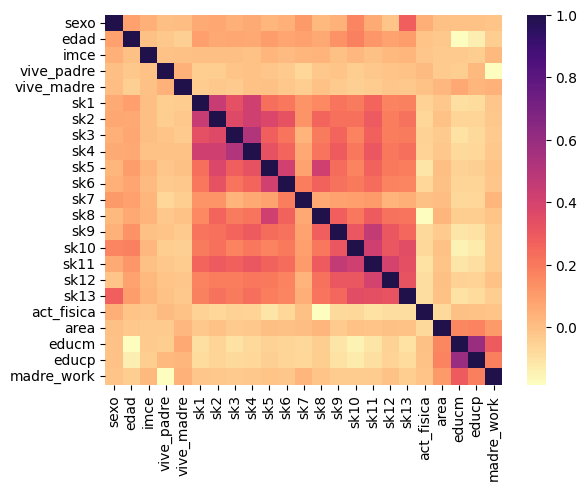

In [45]:
#grafico de correlacion entre factores
sns.heatmap(data=df.corr(), cmap="magma_r", center=0.5)


Notas propias

In [46]:
for i in range(1,4):
    print(f"PARA EL FACTOR {i}")
    print(dfa.corr()[f"F{i}"])
    print("\n")



PARA EL FACTOR 1
sexo          0.134123
edad          0.161821
imce          0.014323
vive_padre   -0.025666
vive_madre   -0.043864
sk1           0.210225
sk2           0.213820
sk3           0.220740
sk4           0.240410
sk5           0.148933
sk6           0.199546
sk7           0.086316
sk8           0.330537
sk9           0.608850
sk10          0.682643
sk11          0.817615
sk12          0.643523
sk13          0.590016
act_fisica   -0.112168
area         -0.015308
educm        -0.139952
educp        -0.122090
madre_work   -0.042472
F1            1.000000
F2            0.150471
F3            0.155945
Name: F1, dtype: float64


PARA EL FACTOR 2
sexo          0.061338
edad          0.066742
imce         -0.010772
vive_padre   -0.027033
vive_madre   -0.025109
sk1           0.670739
sk2           0.636364
sk3           0.728958
sk4           0.850820
sk5           0.265870
sk6           0.252436
sk7           0.092537
sk8           0.121034
sk9           0.254869
sk10          0.150

In [47]:
# Mostrar la correlación de F1 con sk1-sk13 en orden descendente
sk_cols = [f"sk{i}" for i in range(1, 14)]
correlaciones = dfa[sk_cols + ["F1"]].corr()["F1"].drop("F1").sort_values(ascending=False)
print(correlaciones)

sk11    0.817615
sk10    0.682643
sk12    0.643523
sk9     0.608850
sk13    0.590016
sk8     0.330537
sk4     0.240410
sk3     0.220740
sk2     0.213820
sk1     0.210225
sk6     0.199546
sk5     0.148933
sk7     0.086316
Name: F1, dtype: float64


NOTEMOS QUE PARA EL FACTOR 1 LO MAS ALTOS SON LOS QUE EN EFECTO SE ELIGIERON PARA PERTENECER A ESE FACTOR

In [48]:
# Mostrar la correlación de F2 con sk1-sk13 en orden descendente
sk_cols = [f"sk{i}" for i in range(1, 14)]
correlaciones = dfa[sk_cols + ["F2"]].corr()["F2"].drop("F2").sort_values(ascending=False)
print(correlaciones)

sk4     0.850820
sk3     0.728958
sk1     0.670739
sk2     0.636364
sk5     0.265870
sk11    0.256956
sk9     0.254869
sk6     0.252436
sk13    0.188079
sk10    0.150440
sk12    0.135989
sk8     0.121034
sk7     0.092537
Name: F2, dtype: float64


In [49]:
# Mostrar la correlación de F3 con sk1-sk13 en orden descendente
sk_cols = [f"sk{i}" for i in range(1, 14)]
correlaciones = dfa[sk_cols + ["F3"]].corr()["F3"].drop("F3").sort_values(ascending=False)
print(correlaciones)

sk5     0.917654
sk6     0.623155
sk8     0.612696
sk2     0.453663
sk11    0.258640
sk9     0.258162
sk4     0.249059
sk3     0.207335
sk1     0.193918
sk7     0.187715
sk12    0.181170
sk13    0.168653
sk10    0.163724
Name: F3, dtype: float64


fin notas propias

# Pregunta 5

In [50]:
!pip install StepMix

In [51]:
# Clase latente
from stepmix.stepmix import StepMix

In [52]:
# df1 = df con las variables SK xx
# df = df con variables y sk
# dfa = df con todo + columnas de scores de cada infividuo a cada factor, asi como lo que valen los factores para cada observación
# posteriormente estara df2, que es el df normal pero solo con el imce


d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  2.76it/s, max_LL=-1.2e+6, max_avg_LL=-40.3]
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\si

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.35it/s, max_LL=-1.08e+6, max_avg_LL=-36.4]
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\s

...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:13<00:00, 13.32s/it, max_LL=-9.88e+5, max_avg_LL=-33.3]
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\s

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:11<00:00, 11.51s/it, max_LL=-9.96e+5, max_avg_LL=-33.5]
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: >

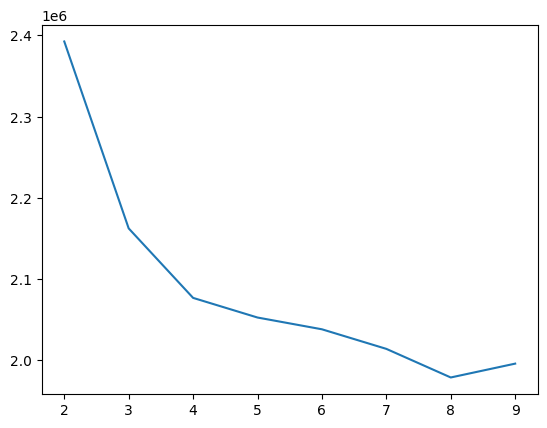

In [53]:
# No deben haber NANS     <-----  MIRA AQUI ||||||


# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df))

sns.lineplot(x = K, y = BIC)  

In [54]:
# revisado


#df=pd.read_csv('../data/junaeb3.csv')
df2=df[['imce']]

from stepmix.stepmix import StepMix
model = StepMix(n_components=3, measurement="gaussian_diag", verbose=1, random_state=123).fit(df2)

d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:09<00:00,  9.03s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                
          class_no                         0       1       2
          param       variable                              
          covariances imce            0.9629  1.4229  2.7533
          means       imce            0.5012  1.8813 -0.0576
    Class weights
        Class 1 : 0.49
        Class 2 : 0.41
        Class 3 : 0.10
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 8
    Log-likelihood (LL)           : -51339.8343
    -2LL                          : 102679.6686
    Average LL                    : -1.7288
    AIC                           : 102695.67
    BIC                           : 102762.06
    CAIC                          : 102770.06
    Sample-Size Adjusted BIC      : 102819.02
    Entropy                       : 22029.9267
 


d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` i

In [55]:
df2

,imce
1,0.71
3,2.05
4,1.05
5,1.39
6,2.75
...,...
31050,1.63
31051,2.57
31052,2.12
31053,-0.43


In [56]:
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,1,4.0,0,8.0,8,-1
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,3,2,2,2.0,1,20.0,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,...,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,...,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,1,2,1,1,2,2.0,1,17.0,15,1


PROBAMOS ELIMINAR SK/

In [57]:
df_step = df.drop(columns=["sk7"])
df_step.columns

Index(['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'sk1', 'sk2', 'sk3',
       'sk4', 'sk5', 'sk6', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13',
       'act_fisica', 'area', 'educm', 'educp', 'madre_work'],
      dtype='object')

In [58]:
df1

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
1,1,1,1,1,1,1,4,1,1,1,1,1,1
3,1,1,1,1,1,1,2,1,1,1,1,1,1
4,1,1,1,1,1,1,3,1,1,1,1,1,1
5,1,2,1,1,1,1,4,1,1,1,1,1,1
6,1,1,1,2,2,2,3,2,3,3,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,1,3,1,2,2,1,1,3,2,2,2,1,1
31051,1,1,2,2,1,1,1,2,1,3,2,1,4
31052,1,1,1,1,1,1,1,1,1,3,1,1,1
31053,1,1,1,1,2,2,1,2,1,2,1,1,2


In [59]:
# Continuous StepMix Model with 3 latent classes

model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

# Fit model and predict clusters
df_solo=df[['imce']]
model.fit(df_solo)
df2['pred']=model.predict(df_solo)

d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.16s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475



d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
d:\benja\Universidad\PYTHON(LENGUAJE)\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all

In [60]:
df2

,imce,pred
1,0.71,2
3,2.05,1
4,1.05,2
5,1.39,2
6,2.75,1
...,...,...
31050,1.63,2
31051,2.57,1
31052,2.12,1
31053,-0.43,2


In [61]:
df2

,imce,pred
1,0.71,2
3,2.05,1
4,1.05,2
5,1.39,2
6,2.75,1
...,...,...
31050,1.63,2
31051,2.57,1
31052,2.12,1
31053,-0.43,2


C:\Users\benja\AppData\Local\Temp\ipykernel_4144\1630985841.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='pred',y="imce",palette="bright", showfliers=False)


<Axes: xlabel='pred', ylabel='imce'>

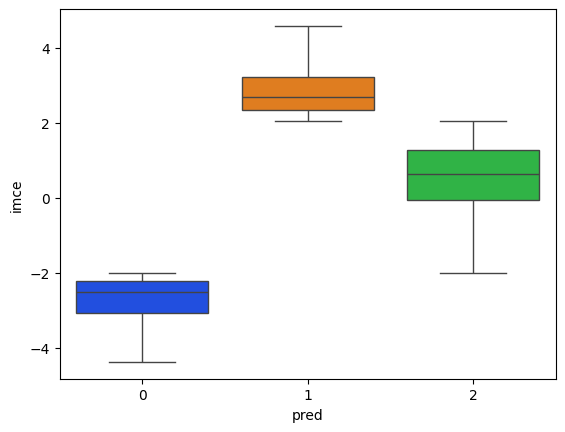

In [62]:
sns.boxplot(data=df2, x='pred',y="imce",palette="bright", showfliers=False)


# Respuesta pregunta 5
SE PUEDE CONCLUIR QUE LA SEPARACION QUE SE HIZO FUE PRODUCTO DE ENCONRAR 3 GRUPOS DE PERSONAS, EL AZUL, PERSONAS CON UN IMCE MUY BAJO, TENDIENDO A DESNUTRICION, OTRO, VERDE, DONDE ESTA LA MAYORIA DE LOS INDIVIDUOS, EN UN RANGO "NORMAL", Y OTRO, NARANJO, QUE HABLA DEL GRUPO QUE TIENE SOBREPESO EN EXCESO

NOTAR QUE EL GRUPO VERDE IGUAL TIENE ALGUNAS PERSONAS DE IMCE ALGO ALTO, PERO CLARO...EL GRUPO NARANJO ES CLARAMENTE UN EXTREMO


# Pregunta 6

MODELO SEM BASADO EN CFA

=~ define factores latentes

~ relaciona

In [63]:
df.columns

Index(['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'sk1', 'sk2', 'sk3',
       'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12',
       'sk13', 'act_fisica', 'area', 'educm', 'educp', 'madre_work'],
      dtype='object')

In [64]:
df2

,imce,pred
1,0.71,2
3,2.05,1
4,1.05,2
5,1.39,2
6,2.75,1
...,...,...
31050,1.63,2
31051,2.57,1
31052,2.12,1
31053,-0.43,2


In [65]:
# Especificar el modelo en sintaxis estándar de SEM


#Recuerda cambiar sk7 a su original en interactividad


modelo = """



# measurement model
INTERES =~ sk9 + sk10 + sk11 + sk12 + sk13
EXPRESIVIDAD =~ sk1 + sk2 + sk3 + sk4 +sk7
INTERACTIVIDAD =~ sk5 + sk6  +sk8


# Relación estructural
imce ~ INTERES + EXPRESIVIDAD + INTERACTIVIDAD + act_fisica


act_fisica ~~ sk8 +sk5
INTERES ~~ INTERACTIVIDAD


"""


#relacion entre jugar con otros y actividad grupal relacionado a actividad fisica

model = semopy.Model(modelo)
out=model.fit(df)
print(out)
print(model.inspect())



# Evaluar ajuste del modelo
print(model.inspect("fit"))

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.196
Number of iterations: 53
Params: 1.350 1.249 1.096 1.273 1.880 1.624 1.825 0.824 1.029 1.132 0.004 -0.275 0.226 -0.019 -0.115 -0.029 0.089 0.152 0.052 0.049 0.159 0.058 1.871 0.095 0.595 0.200 0.442 0.714 0.240 0.201 0.160 0.151 0.371 1.430 0.473 0.278
              lval  op            rval  Estimate  Std. Err     z-value  \
0              sk9   ~         INTERES  1.000000         -           -   
1             sk10   ~         INTERES  1.349542  0.018552   72.745314   
2             sk11   ~         INTERES  1.248745  0.014751   84.654497   
3             sk12   ~         INTERES  1.095991  0.015523   70.606431   
4             sk13   ~         INTERES  1.272632  0.018916   67.276369   
5              sk1   ~    EXPRESIVIDAD  1.000000         -           -   
6              sk2   ~    EXPRESIVIDAD  1.879749   0.02364   79.515123   
7              sk3  

In [66]:
#version anterior
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,84,106,5807.69965,0.0,83671.80356,0.931507,0.93059,0.912411,0.93059,0.913568,0.047902,71.608856,370.364491,0.195572


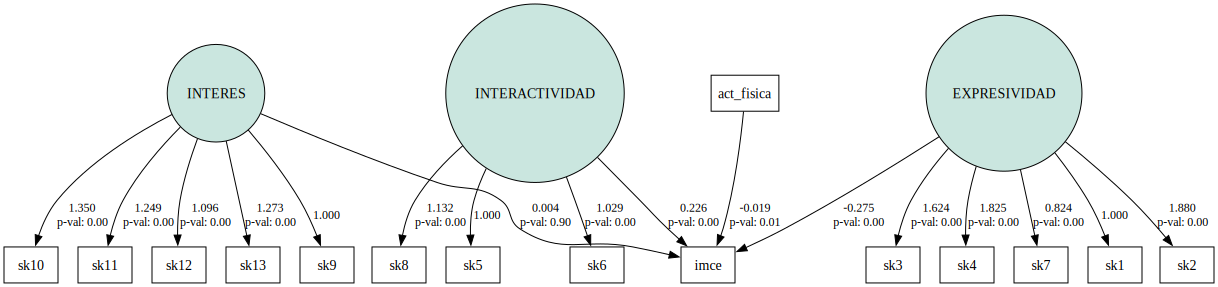

In [67]:
import os
os.environ["PATH"] += os.pathsep + r"d:\benja\Universidad\PYTHON(LENGUAJE)\libreria Graphviz instalador o el ejecutable(.exe)\Graphviz\bin"
##no queria actualizar el path, solo asi funciona :D
#despues de ejecutarlo, para su reejecucion parece funcionar igual

# Ahora intenta de nuevo:
import semopy
semopy.semplot(model, "semmodel.png")


In [68]:
#version final
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,84,106,5807.69965,0.0,83671.80356,0.931507,0.93059,0.912411,0.93059,0.913568,0.047902,71.608856,370.364491,0.195572


# respuesta pregunta 6

DE LAS METRICAS NOTEMOS QUE EL TLI CFI RMSEA:

TLI > 90%

RMSEA < 0.5%

CFI = 0.93 <0.95 (no es lo ideal) pero esta bastante bien

al considerar el imce como objeto de variacion el ajuste a los grupos es mucho mejor, ya que para las demas variables si bien hay diferencias, estas son minimas con la evidente diferencia que hay de los individuos en cuanto a su indice de masa corporal. Mas se decidio agregar la actividad fisica pues debe ser clave para su salud fisica, ademas, si bien puede jugar, esto habla de la frecuencia y o "intensidad" de sus actividades a lo largo del tiempo.
mas de descartaron otras variables como la edad o el sexo por no ser relevantes a la hora de segmentar, puesto que para la edad la variabilidad es muy baja, y para sexo se vio antes que esta no afectaba a este grupo etario en mayor medida. respecto a los padres, se considero mas pertinente su actuar mas que esten, y puesto que se indique su interaccion indirectamente habla de su presencia, es decir, se cree mas relevante la interacción.




# PREGUNTA 7

In [69]:
# Agregamos la columna 'pred' de df2 a df
df['pred'] = df2['pred']

# Separamos df en tres grupos según el valor de la columna 'pred'
df_grupo0 = df[df['pred'] == 0].copy()
df_grupo1 = df[df['pred'] == 1].copy()
df_grupo2 = df[df['pred'] == 2].copy()


In [70]:
df_grupo0

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,pred
39,1,84,-2.37,1,1,1,3,1,1,1,...,3,3,1,5,5.0,1,6.0,9,-1,0
108,0,105,-3.30,1,1,2,2,2,2,2,...,2,2,2,2,2.0,1,8.0,12,-1,0
163,1,105,-3.40,1,1,1,1,1,1,2,...,3,2,2,3,3.0,0,11.0,2,-1,0
243,0,102,-3.80,0,1,1,2,2,2,2,...,3,3,3,2,1.0,1,9.0,12,0,0
451,1,98,-2.51,0,1,1,1,1,1,1,...,1,1,1,1,3.0,1,9.0,9,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30544,0,80,-2.82,1,1,1,1,1,1,1,...,1,1,1,3,5.0,1,13.0,13,-1,0
30711,0,79,-3.39,1,1,1,1,1,1,2,...,2,1,1,1,4.0,1,13.0,13,-1,0
30742,1,79,-2.13,0,1,2,2,1,1,2,...,3,1,2,1,3.0,1,13.0,13,-1,0
30819,1,80,-2.36,1,1,1,2,1,1,1,...,3,1,1,3,2.0,1,12.0,11,-1,0


In [71]:
df_grupo1

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,pred
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,1
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,2,2,2.0,1,20.0,19,1,1
17,1,74,2.53,1,1,1,2,1,1,1,...,1,1,1,1,2.0,1,13.0,13,1,1
24,0,85,3.41,0,1,2,3,1,2,2,...,2,2,2,2,2.0,0,13.0,13,0,1
25,1,84,2.98,1,1,1,1,1,1,1,...,1,1,1,4,3.0,0,9.0,9,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31034,0,79,3.04,1,1,1,1,3,1,2,...,2,1,1,1,4.0,1,13.0,13,1,1
31035,0,80,3.22,1,1,1,1,2,1,3,...,3,1,2,1,2.0,1,13.0,13,1,1
31045,0,78,2.82,0,1,1,1,1,1,1,...,2,1,2,1,3.0,1,19.0,19,1,1
31051,1,79,2.57,1,1,1,1,2,2,1,...,3,2,1,4,3.0,1,18.0,19,0,1


In [72]:
df_grupo2

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,pred
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,2
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,2
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,4.0,0,8.0,8,-1,2
7,1,92,1.53,1,1,1,3,1,1,3,...,4,3,2,4,1.0,1,13.0,11,0,2
8,1,69,1.96,1,1,1,2,3,2,1,...,4,2,2,3,2.0,0,10.0,9,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31048,1,78,1.58,1,1,1,1,1,1,1,...,4,3,3,5,1.0,0,13.0,12,-1,2
31049,1,79,1.73,1,0,1,1,2,1,1,...,1,2,1,2,2.0,1,17.0,17,1,2
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,1,1,2.0,1,13.0,13,-1,2
31053,1,78,-0.43,1,1,1,1,1,1,2,...,2,1,1,2,2.0,1,17.0,15,1,2


modelo para grupo 0:

In [73]:

modelo = """



# measurement model
INTERES =~ sk9 + sk10 + sk11 + sk12 + sk13
EXPRESIVIDAD =~ sk1 + sk2 + sk3 + sk4 +sk7
INTERACTIVIDAD =~ sk5 + sk6  +sk8


# Relación estructural
imce ~ INTERES + EXPRESIVIDAD + INTERACTIVIDAD + act_fisica


act_fisica ~~ sk8 +sk5
INTERES ~~ INTERACTIVIDAD


"""


#relacion entre jugar con otros y actividad grupal relacionado a actividad fisica

model = semopy.Model(modelo)
out=model.fit(df_grupo0)
print(out)
print(model.inspect())



# Evaluar ajuste del modelo
print(model.inspect("fit"))

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.512
Number of iterations: 54
Params: 1.055 1.117 0.827 1.077 2.466 2.187 2.759 1.134 1.093 1.253 -0.121 1.101 -0.449 0.080 -0.155 -0.000 0.091 0.223 0.047 0.028 0.152 0.048 0.469 0.081 0.653 0.215 0.350 0.762 0.240 0.199 0.140 0.165 0.407 1.496 0.541 0.281
              lval  op            rval  Estimate  Std. Err    z-value  \
0              sk9   ~         INTERES  1.000000         -          -   
1             sk10   ~         INTERES  1.055059  0.120338   8.767439   
2             sk11   ~         INTERES  1.117027  0.099458  11.231107   
3             sk12   ~         INTERES  0.827340  0.090557   9.136115   
4             sk13   ~         INTERES  1.077198  0.127243   8.465651   
5              sk1   ~    EXPRESIVIDAD  1.000000         -          -   
6              sk2   ~    EXPRESIVIDAD  2.465914  0.287997   8.562293   
7              sk3   ~    EX

In [74]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,84,106,212.133768,4.659606e-13,1370.658867,0.898681,0.845232,0.804698,0.845232,0.872145,0.060774,70.975199,215.906374,0.5124


modelo para el grupo 1:

In [75]:
modelo = """



# measurement model
INTERES =~ sk9 + sk10 + sk11 + sk12 + sk13
EXPRESIVIDAD =~ sk1 + sk2 + sk3 + sk4 +sk7
INTERACTIVIDAD =~ sk5 + sk6  +sk8


# Relación estructural
imce ~ INTERES + EXPRESIVIDAD + INTERACTIVIDAD + act_fisica


act_fisica ~~ sk8 +sk5
INTERES ~~ INTERACTIVIDAD


"""


#relacion entre jugar con otros y actividad grupal relacionado a actividad fisica

model = semopy.Model(modelo)
out=model.fit(df_grupo1)
print(out)
print(model.inspect())



# Evaluar ajuste del modelo
print(model.inspect("fit"))

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.221
Number of iterations: 40
Params: 1.365 1.244 1.142 1.360 1.811 1.464 1.628 0.855 0.985 1.075 0.020 -0.132 0.135 0.003 -0.121 -0.032 0.097 0.156 0.055 0.058 0.184 0.065 0.453 0.096 0.625 0.210 0.470 0.742 0.243 0.218 0.163 0.164 0.396 1.478 0.529 0.273
              lval  op            rval  Estimate  Std. Err    z-value  \
0              sk9   ~         INTERES  1.000000         -          -   
1             sk10   ~         INTERES  1.364937  0.039081  34.925519   
2             sk11   ~         INTERES  1.244434  0.030567  40.712069   
3             sk12   ~         INTERES  1.141896  0.033278  34.313474   
4             sk13   ~         INTERES  1.360070  0.040764  33.364838   
5              sk1   ~    EXPRESIVIDAD  1.000000         -          -   
6              sk2   ~    EXPRESIVIDAD  1.811222   0.04611  39.280764   
7              sk3   ~    EXP

In [76]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,84,106,1475.831645,0.0,19105.43338,0.926744,0.922753,0.902522,0.922753,0.907557,0.049812,71.558068,316.600116,0.220966


modelo para el grupo 2

In [77]:
modelo = """



# measurement model
INTERES =~ sk9 + sk10 + sk11 + sk12 + sk13
EXPRESIVIDAD =~ sk1 + sk2 + sk3 + sk4 +sk7
INTERACTIVIDAD =~ sk5 + sk6  +sk8


# Relación estructural
imce ~ INTERES + EXPRESIVIDAD + INTERACTIVIDAD + act_fisica


act_fisica ~~ sk8 +sk5
INTERES ~~ INTERACTIVIDAD


"""


#relacion entre jugar con otros y actividad grupal relacionado a actividad fisica

model = semopy.Model(modelo)
out=model.fit(df_grupo2)
print(out)
print(model.inspect())



# Evaluar ajuste del modelo
print(model.inspect("fit"))

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.191
Number of iterations: 44
Params: 1.348 1.253 1.088 1.247 1.893 1.670 1.877 0.799 1.043 1.148 -0.019 -0.052 0.017 -0.003 -0.112 -0.028 0.087 0.149 0.051 0.047 0.151 0.055 0.825 0.094 0.585 0.196 0.435 0.704 0.239 0.196 0.160 0.146 0.363 1.411 0.455 0.279
              lval  op            rval  Estimate  Std. Err     z-value  \
0              sk9   ~         INTERES  1.000000         -           -   
1             sk10   ~         INTERES  1.347718  0.021349   63.128362   
2             sk11   ~         INTERES  1.252889  0.017065   73.419018   
3             sk12   ~         INTERES  1.088304  0.017813   61.096667   
4             sk13   ~         INTERES  1.247394  0.021596   57.761252   
5              sk1   ~    EXPRESIVIDAD  1.000000         -           -   
6              sk2   ~    EXPRESIVIDAD  1.892808  0.027577   68.637677   
7              sk3 

In [78]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,84,106,4312.07052,0.0,63405.212218,0.933205,0.931992,0.91418,0.931992,0.915711,0.047191,71.618451,360.548617,0.190774


# Respuesta pregunta 7:

AL realizar el analisis pero esta vez en grupos, podemos decir para el caso del grupo...

grupo 0(desnutricion): no descrimina bien, no se parece al caso global de la pregunta 6


grupo 1(obesidad): descrimina bien, incluso parecido al caso global de la pregunta 6


grupo 2(rango normal): descrimina bien, incluso parecido al caso global de la pregunta 6


hay una diferencia en los casos del grupo 1 y 2, que es poca, mas el caso global tiene estadisticas ligeramente mayores, mas a priori, lo hicieron bien ambos, mas para el caso del grupo 0, esto no sucedio, tuvo un peor desempeño en todos los parametros considerablemente, bajando del 0.9 incluso, para los otros 2 su baja es apenas del 0.1-0.2 pero solo en el tli, por lo que puede indicar que el ajuste a los datos en este caso en un poco mas bajo.

estas diferencias principlamente se deberan a que los rangos de valores de las variables abarcan tanto al grupo 1 o 2, pero al grupo 0 lo dejan mas resagado, ademas que el valor del imce esta mucho mas alejado de cada uno de los otros grupos, no tan asi la situacion entre grupo 1 y 2